In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime

random.seed(42)
np.random.seed(42)

%matplotlib inline

In [5]:
IMAGE_DIR = r"C:\Users\PC-LAB1\img_processing_lab\project_1_crack_segmentation\data\train\images"   # <-- update this
MASK_DIR  = r"C:\Users\PC-LAB1\img_processing_lab\project_1_crack_segmentation\data\train\masks"    # <-- update this

def index_by_stem(folder):
    """Map filename stem (no extension) -> full path. Avoids relying on os.listdir order."""
    d = {}
    for fname in os.listdir(folder):
        stem = os.path.splitext(fname)[0]
        d[stem] = os.path.join(folder, fname)
    return d

image_dict = index_by_stem(IMAGE_DIR)
mask_dict  = index_by_stem(MASK_DIR)

common_keys = sorted(set(image_dict) & set(mask_dict))
only_images = sorted(set(image_dict) - set(mask_dict))
only_masks  = sorted(set(mask_dict) - set(image_dict))

print(f"Images found    : {len(image_dict)}")
print(f"Masks found     : {len(mask_dict)}")
print(f"Matched pairs   : {len(common_keys)}")
print(f"Images w/o mask : {len(only_images)}")
print(f"Masks w/o image : {len(only_masks)}")

if only_images:
    print("Example unmatched images:", only_images[:5])
if only_masks:
    print("Example unmatched masks:", only_masks[:5])

Images found    : 9603
Masks found     : 9603
Matched pairs   : 9603
Images w/o mask : 0
Masks w/o image : 0


In [6]:
experiment_log = []

def log_experiment(step_name, params, metrics, notes=""):
    """Append one experiment result to the running log and print a readable summary."""
    entry = {
        "step": step_name,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "params": params,
        "notes": notes,
    }
    entry.update(metrics)
    experiment_log.append(entry)

    print(f"========== LOGGED [{step_name}] ==========")
    print(f"Params : {params}")
    for k, v in metrics.items():
        print(f"{k:12s}: {v}")
    if notes:
        print(f"Notes  : {notes}")
    print("=" * 45)

def show_log():
    """Return the full experiment log as a DataFrame, most recent last."""
    return pd.DataFrame(experiment_log)

def save_log(path="experiment_log.json"):
    with open(path, "w") as f:
        json.dump(experiment_log, f, indent=2, default=str)
    print(f"Saved {len(experiment_log)} entries to {path}")

In [7]:
def get_image_shape(key):
    """Read just enough to get (H, W). Returns None on failure."""
    img = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    if img is None:
        return key, None
    return key, img.shape[:2]

print(f"Scanning {len(common_keys)} images for resolution + filename patterns...")

results = Parallel(n_jobs=-1)(delayed(get_image_shape)(k) for k in common_keys)

resolutions = {}
failed_reads = []
for key, shape in results:
    if shape is None:
        failed_reads.append(key)
    else:
        resolutions[key] = shape

prefixes = [k.split('_')[0] if '_' in k else 'Unknown' for k in common_keys]
prefix_counts = Counter(prefixes)
resolution_counts = Counter(resolutions.values())

print("\n" + "=" * 50)
print("     DATASET HETEROGENEITY DIAGNOSTIC REPORT")
print("=" * 50)

print(f"\nFailed reads: {len(failed_reads)}")
if failed_reads:
    print("Examples:", failed_reads[:5])

print("\nFilename Prefix Distribution:")
for prefix, count in prefix_counts.most_common(15):
    print(f"  - {prefix:15s}: {count:5d} images ({count/len(common_keys)*100:.1f}%)")

print("\nImage Resolution Breakdown (H x W), top 15:")
for res, count in resolution_counts.most_common(15):
    print(f"  - {str(res):15s}: {count:5d} images ({count/len(common_keys)*100:.1f}%)")
print(f"\nTotal distinct resolutions: {len(resolution_counts)}")

log_experiment(
    step_name="Dataset Heterogeneity Diagnostic",
    params={"n_images": len(common_keys)},
    metrics={
        "n_distinct_prefixes": len(prefix_counts),
        "n_distinct_resolutions": len(resolution_counts),
        "top_prefix": prefix_counts.most_common(1)[0] if prefix_counts else None,
        "top_resolution": resolution_counts.most_common(1)[0] if resolution_counts else None,
        "failed_reads": len(failed_reads),
    },
)

Scanning 9603 images for resolution + filename patterns...

     DATASET HETEROGENEITY DIAGNOSTIC REPORT

Failed reads: 0

Filename Prefix Distribution:
  - Rissbilder     :  3249 images (33.8%)
  - CRACK500       :  2858 images (29.8%)
  - noncrack       :  1199 images (12.5%)
  - Volker         :   842 images (8.8%)
  - DeepCrack      :   443 images (4.6%)
  - GAPS384        :   433 images (4.5%)
  - cracktree200   :   175 images (1.8%)
  - Sylvie         :   157 images (1.6%)
  - CFD            :   100 images (1.0%)
  - forest         :   100 images (1.0%)
  - Eugen          :    47 images (0.5%)

Image Resolution Breakdown (H x W), top 15:
  - (448, 448)     :  9603 images (100.0%)

Total distinct resolutions: 1
========== LOGGED [Dataset Heterogeneity Diagnostic] ==========
Params : {'n_images': 9603}
n_distinct_prefixes: 11
n_distinct_resolutions: 1
top_prefix  : ('Rissbilder', 3249)
top_resolution: ((448, 448), 9603)
failed_reads: 0


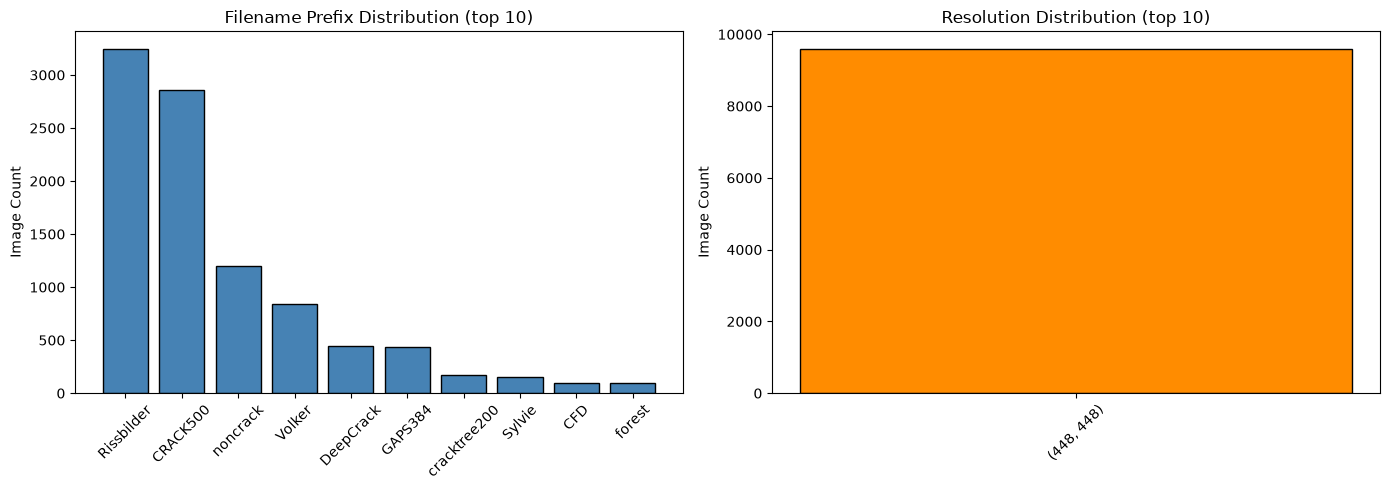

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_prefixes = prefix_counts.most_common(10)
axes[0].bar([p[0] for p in top_prefixes], [p[1] for p in top_prefixes], color='steelblue', edgecolor='black')
axes[0].set_title("Filename Prefix Distribution (top 10)")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis='x', rotation=45)

top_res = resolution_counts.most_common(10)
res_labels = [f"{r[0]}" for r in top_res]
axes[1].bar(res_labels, [r[1] for r in top_res], color='darkorange', edgecolor='black')
axes[1].set_title("Resolution Distribution (top 10)")
axes[1].set_ylabel("Image Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
def binarize_gt_mask(mask_path, thresh=127):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return (m > thresh).astype(np.uint8)

def gt_pixel_count(key):
    mask = binarize_gt_mask(mask_dict[key])
    return key, int(mask.sum())

print("Scanning ground-truth masks for crack pixel counts...")
gt_results = Parallel(n_jobs=-1)(delayed(gt_pixel_count)(k) for k in common_keys)
gt_pixels = dict(gt_results)

empty_mask_keys = [k for k, v in gt_pixels.items() if v == 0]
empty_by_prefix = Counter(k.split('_')[0] if '_' in k else 'Unknown' for k in empty_mask_keys)

print(f"\nTotal images with EMPTY (all-zero) ground truth: {len(empty_mask_keys)} "
      f"({len(empty_mask_keys)/len(common_keys)*100:.1f}%)")
print("\nEmpty-mask images by prefix:")
for prefix, count in empty_by_prefix.most_common():
    total_in_prefix = prefix_counts[prefix]
    print(f"  - {prefix:15s}: {count:5d} / {total_in_prefix:5d} ({count/total_in_prefix*100:.1f}%)")

log_experiment(
    step_name="Ground Truth Emptiness Audit",
    params={"n_images": len(common_keys)},
    metrics={
        "n_empty_masks": len(empty_mask_keys),
        "pct_empty": round(len(empty_mask_keys) / len(common_keys) * 100, 2),
    },
)

Scanning ground-truth masks for crack pixel counts...

Total images with EMPTY (all-zero) ground truth: 1233 (12.8%)

Empty-mask images by prefix:
  - noncrack       :  1199 /  1199 (100.0%)
  - Rissbilder     :    30 /  3249 (0.9%)
  - Sylvie         :     3 /   157 (1.9%)
  - Volker         :     1 /   842 (0.1%)
========== LOGGED [Ground Truth Emptiness Audit] ==========
Params : {'n_images': 9603}
n_empty_masks: 1233
pct_empty   : 12.84


In [10]:
def filter_wear_parametric(binary_img, min_aspect_ratio=2.2, max_solidity=0.65, min_area=30):
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = np.zeros_like(binary_img)
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = max(w, h) / (min(w, h) + 1e-6)
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        if aspect_ratio >= min_aspect_ratio or solidity <= max_solidity:
            cv2.drawContours(output, [c], -1, 255, thickness=cv2.FILLED)
    return output

def process_image_sauvola(key, window_size=45, k=0.2, min_aspect_ratio=2.2,
                           max_solidity=0.65, min_area=30, clip_limit=1.0, tile_grid=(4, 4)):
    gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    blurred = cv2.medianBlur(gray, 5)
    clahe_img = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(blurred)
    sauv_t = threshold_sauvola(clahe_img, window_size=window_size, k=k)
    thresh = (clahe_img < sauv_t).astype(np.uint8) * 255
    pred = filter_wear_parametric(thresh, min_aspect_ratio, max_solidity, min_area)
    return pred

def compute_metrics(pred, gt):
    """
    Explicit convention for empty ground truth:
    - gt has 0 crack pixels AND pred has 0 pixels -> IoU = 1.0, Dice = 1.0 (correct rejection)
    - gt has 0 crack pixels AND pred has >0 pixels -> IoU = 0.0, Dice = 0.0 (pure false positive)
    - precision/recall are undefined (None) for empty-GT images -- there's no positive class to score
    """
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)

    intersection = int(np.logical_and(pred_bin, gt_bin).sum())
    pred_sum = int(pred_bin.sum())
    gt_sum = int(gt_bin.sum())

    is_negative = (gt_sum == 0)

    if is_negative:
        iou = 1.0 if pred_sum == 0 else 0.0
        dice = 1.0 if pred_sum == 0 else 0.0
        precision, recall = None, None
    else:
        union = pred_sum + gt_sum - intersection
        iou = intersection / union if union > 0 else 0.0
        dice = (2 * intersection) / (pred_sum + gt_sum) if (pred_sum + gt_sum) > 0 else 0.0
        precision = intersection / pred_sum if pred_sum > 0 else 0.0
        recall = intersection / gt_sum

    return {"iou": iou, "dice": dice, "precision": precision, "recall": recall,
            "is_negative": is_negative, "pred_pixels": pred_sum, "gt_pixels": gt_sum}

In [11]:
def evaluate_one(key):
    gt = binarize_gt_mask(mask_dict[key])
    pred = process_image_sauvola(key)  # using current defaults: window=45, k=0.2, aspect=2.2, solidity=0.65
    m = compute_metrics(pred, gt)
    m["key"] = key
    return m

print(f"Evaluating {len(common_keys)} images (stratified crack / no-crack)...")
full_results = Parallel(n_jobs=-1)(delayed(evaluate_one)(k) for k in common_keys)
df = pd.DataFrame(full_results)

crack_df = df[~df.is_negative]
neg_df = df[df.is_negative]

specificity = (neg_df.pred_pixels == 0).mean()
mean_fp_pixels_on_negatives = neg_df.pred_pixels.mean()

print("\n" + "=" * 55)
print("   STRATIFIED FULL-DATASET METRICS")
print("=" * 55)
print(f"Crack-containing images (n={len(crack_df)}):")
print(f"  Mean IoU     : {crack_df.iou.mean():.4f}")
print(f"  Median IoU   : {crack_df.iou.median():.4f}")
print(f"  Mean Dice    : {crack_df.dice.mean():.4f}")
print(f"  Mean Precision: {crack_df.precision.mean():.4f}")
print(f"  Mean Recall   : {crack_df.recall.mean():.4f}")
print(f"\nNo-crack images (n={len(neg_df)}):")
print(f"  Specificity (correct empty prediction rate): {specificity:.4f}")
print(f"  Mean false-positive pixels per image        : {mean_fp_pixels_on_negatives:.1f}")
print("=" * 55)

log_experiment(
    step_name="Stratified Full 9,603 Evaluation (Sauvola, crack vs no-crack split)",
    params={"window_size": 45, "k": 0.2, "min_aspect_ratio": 2.2, "max_solidity": 0.65},
    metrics={
        "crack_mean_iou": round(crack_df.iou.mean(), 4),
        "crack_median_iou": round(crack_df.iou.median(), 4),
        "crack_mean_dice": round(crack_df.dice.mean(), 4),
        "crack_mean_precision": round(crack_df.precision.mean(), 4),
        "crack_mean_recall": round(crack_df.recall.mean(), 4),
        "negative_specificity": round(specificity, 4),
        "negative_mean_fp_pixels": round(mean_fp_pixels_on_negatives, 2),
    },
)

Evaluating 9603 images (stratified crack / no-crack)...

   STRATIFIED FULL-DATASET METRICS
Crack-containing images (n=8370):
  Mean IoU     : 0.1391
  Median IoU   : 0.1033
  Mean Dice    : 0.2225
  Mean Precision: 0.2948
  Mean Recall   : 0.4051

No-crack images (n=1233):
  Specificity (correct empty prediction rate): 0.1071
  Mean false-positive pixels per image        : 7632.0
========== LOGGED [Stratified Full 9,603 Evaluation (Sauvola, crack vs no-crack split)] ==========
Params : {'window_size': 45, 'k': 0.2, 'min_aspect_ratio': 2.2, 'max_solidity': 0.65}
crack_mean_iou: 0.1391
crack_median_iou: 0.1033
crack_mean_dice: 0.2225
crack_mean_precision: 0.2948
crack_mean_recall: 0.4051
negative_specificity: 0.1071
negative_mean_fp_pixels: 7631.95


In [12]:
# Was the earlier 300-sample skewed by prefix? Recreate it with the same seed to check.
random.seed(42)
sample_300 = random.sample(common_keys, 300)
sample_prefixes = Counter(k.split('_')[0] if '_' in k else 'Unknown' for k in sample_300)

print("Prefix composition: full dataset vs earlier 300-sample")
print(f"{'Prefix':15s}{'Full %':>10s}{'Sample %':>12s}")
for prefix in prefix_counts:
    full_pct = prefix_counts[prefix] / len(common_keys) * 100
    samp_pct = sample_prefixes.get(prefix, 0) / 300 * 100
    print(f"{prefix:15s}{full_pct:9.1f}%{samp_pct:11.1f}%")

# Per-prefix IoU on crack-containing images -- this is the real heterogeneity test
crack_df = crack_df.copy()
crack_df["prefix"] = crack_df["key"].apply(lambda k: k.split('_')[0] if '_' in k else 'Unknown')

per_prefix = crack_df.groupby("prefix").agg(
    n=("iou", "count"),
    mean_iou=("iou", "mean"),
    median_iou=("iou", "median"),
    mean_recall=("recall", "mean"),
    mean_precision=("precision", "mean"),
).sort_values("mean_iou", ascending=False)

print("\nPer-prefix performance (crack-containing images only):")
print(per_prefix.round(4))

log_experiment(
    step_name="Per-Prefix Heterogeneity Breakdown",
    params={"config": "window=45, k=0.2, aspect=2.2, solidity=0.65"},
    metrics={"per_prefix_iou_range": f"{per_prefix.mean_iou.min():.4f} - {per_prefix.mean_iou.max():.4f}"},
    notes="See printed table for full per-source breakdown"
)

Prefix composition: full dataset vs earlier 300-sample
Prefix             Full %    Sample %
CFD                  1.0%        1.0%
CRACK500            29.8%       31.0%
DeepCrack            4.6%        3.7%
Eugen                0.5%        0.3%
GAPS384              4.5%        7.3%
Rissbilder          33.8%       31.7%
Sylvie               1.6%        0.7%
Volker               8.8%        8.0%
cracktree200         1.8%        1.3%
forest               1.0%        1.0%
noncrack            12.5%       14.0%

Per-prefix performance (crack-containing images only):
                 n  mean_iou  median_iou  mean_recall  mean_precision
prefix                                                               
DeepCrack      443    0.4549      0.4558       0.8408          0.5109
CFD            100    0.3274      0.3453       0.4640          0.5739
forest         100    0.3212      0.3424       0.4582          0.5670
GAPS384        433    0.1542      0.1385       0.4948          0.2257
Volker       

In [13]:
density = crack_df.groupby("prefix").agg(
    mean_gt_pixels=("gt_pixels", "mean"),
    mean_pred_pixels=("pred_pixels", "mean"),
).sort_values("mean_gt_pixels")

density["pred_to_gt_ratio"] = density["mean_pred_pixels"] / density["mean_gt_pixels"]
print(density.round(1))

log_experiment(
    step_name="Per-Prefix Label Density Check",
    params={},
    metrics={"note": "compare mean_gt_pixels across prefixes to check for label-thickness convention differences"},
)

              mean_gt_pixels  mean_pred_pixels  pred_to_gt_ratio
prefix                                                          
cracktree200           633.7            6896.7              10.9
GAPS384               2425.1           10138.2               4.2
CFD                   3306.7            2708.7               0.8
forest                3310.7            2686.5               0.8
Rissbilder            5473.5            6510.9               1.2
DeepCrack             7047.4           14334.0               2.0
Volker                8104.7            5886.9               0.7
Eugen                10439.8            2130.4               0.2
CRACK500             12104.1           60021.3               5.0
Sylvie               18789.2            3529.1               0.2
========== LOGGED [Per-Prefix Label Density Check] ==========
Params : {}
note        : compare mean_gt_pixels across prefixes to check for label-thickness convention differences


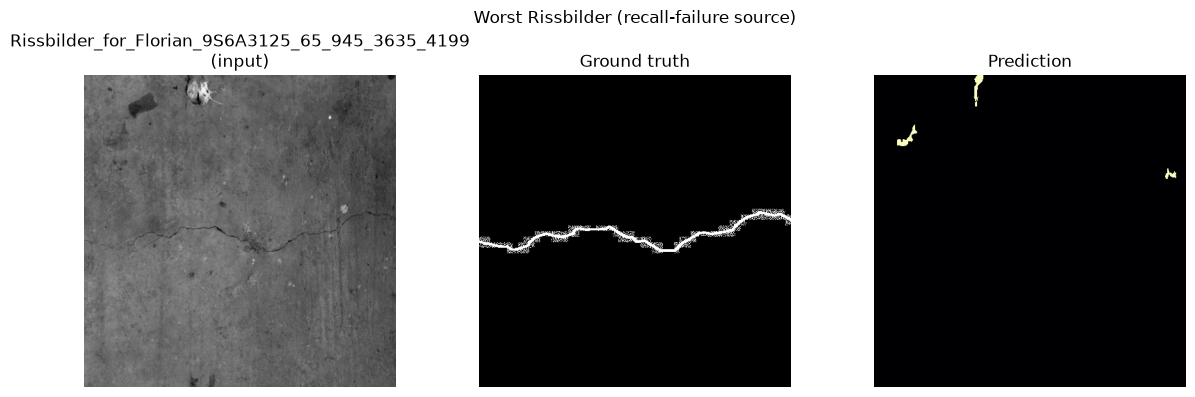

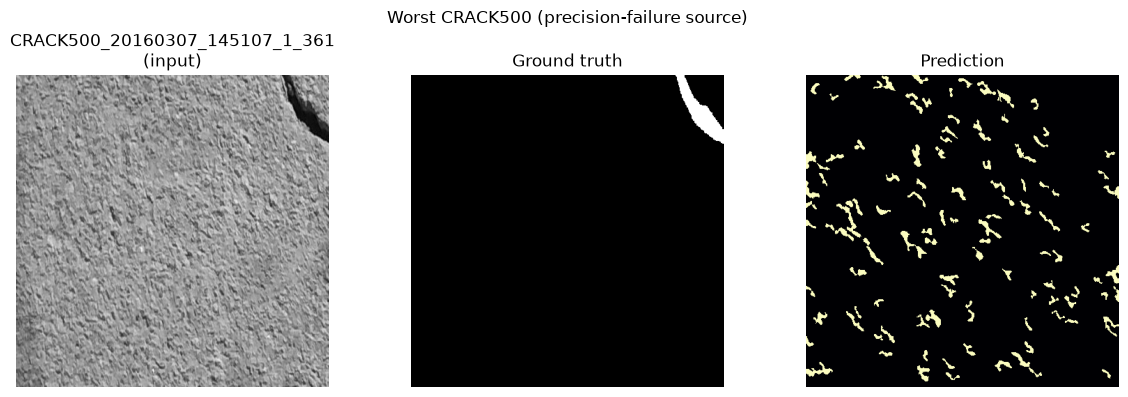

In [14]:
def show_case(key, title):
    gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    gt = binarize_gt_mask(mask_dict[key])
    pred = process_image_sauvola(key)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(gray, cmap='gray'); axes[0].set_title(f"{key}\n(input)"); axes[0].axis('off')
    axes[1].imshow(gt, cmap='gray'); axes[1].set_title("Ground truth"); axes[1].axis('off')
    axes[2].imshow(pred, cmap='magma'); axes[2].set_title("Prediction"); axes[2].axis('off')
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

worst_rissbilder = crack_df[crack_df.prefix == "Rissbilder"].sort_values("iou").iloc[0]["key"]
worst_crack500 = crack_df[crack_df.prefix == "CRACK500"].sort_values("iou").iloc[0]["key"]

show_case(worst_rissbilder, "Worst Rissbilder (recall-failure source)")
show_case(worst_crack500, "Worst CRACK500 (precision-failure source)")

In [15]:
# Cell 12 — GT/prediction pixel density by prefix (label-convention check)
density = crack_df.groupby("prefix").agg(
    mean_gt_pixels=("gt_pixels", "mean"),
    mean_pred_pixels=("pred_pixels", "mean"),
).sort_values("mean_gt_pixels")

density["pred_to_gt_ratio"] = density["mean_pred_pixels"] / density["mean_gt_pixels"]
print(density.round(1))

log_experiment(
    step_name="Per-Prefix Label Density Check",
    params={},
    metrics={
        "min_mean_gt_pixels": float(density["mean_gt_pixels"].min()),
        "max_mean_gt_pixels": float(density["mean_gt_pixels"].max()),
        "min_ratio": float(density["pred_to_gt_ratio"].min()),
        "max_ratio": float(density["pred_to_gt_ratio"].max())
    },
    notes="Comparing mean GT pixel counts and prediction-to-GT ratios across sub-datasets"
)

              mean_gt_pixels  mean_pred_pixels  pred_to_gt_ratio
prefix                                                          
cracktree200           633.7            6896.7              10.9
GAPS384               2425.1           10138.2               4.2
CFD                   3306.7            2708.7               0.8
forest                3310.7            2686.5               0.8
Rissbilder            5473.5            6510.9               1.2
DeepCrack             7047.4           14334.0               2.0
Volker                8104.7            5886.9               0.7
Eugen                10439.8            2130.4               0.2
CRACK500             12104.1           60021.3               5.0
Sylvie               18789.2            3529.1               0.2
========== LOGGED [Per-Prefix Label Density Check] ==========
Params : {}
min_mean_gt_pixels: 633.6914285714286
max_mean_gt_pixels: 18789.16233766234
min_ratio   : 0.18782484099876584
max_ratio   : 10.883440340499206
Not

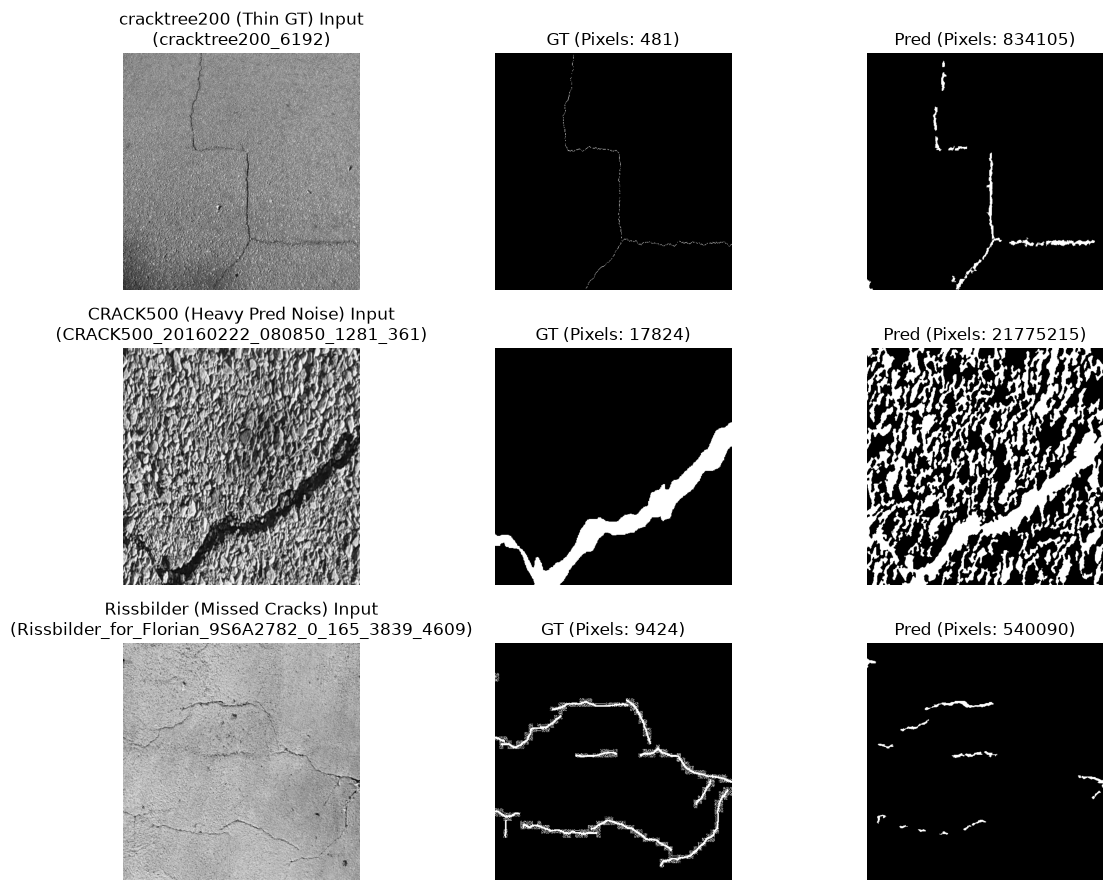

In [16]:
# Cell 13 — Multi-source visual comparison of GT annotations vs predictions
def plot_prefix_samples(samples_dict):
    fig, axes = plt.subplots(len(samples_dict), 3, figsize=(12, 3 * len(samples_dict)))
    
    for idx, (prefix, key) in enumerate(samples_dict.items()):
        gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
        gt = cv2.imread(mask_dict[key], cv2.IMREAD_GRAYSCALE)
        gt_bin = (gt > 127).astype(np.uint8)
        pred = process_image_sauvola(key) # Uses your existing Sauvola function
        
        axes[idx, 0].imshow(gray, cmap='gray')
        axes[idx, 0].set_title(f"{prefix} Input\n({key})")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(gt_bin, cmap='gray')
        axes[idx, 1].set_title(f"GT (Pixels: {np.sum(gt_bin)})")
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(pred, cmap='gray')
        axes[idx, 2].set_title(f"Pred (Pixels: {np.sum(pred)})")
        axes[idx, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Pick one representative crack-containing sample from key sources
sample_keys = {
    "cracktree200 (Thin GT)": crack_df[crack_df.prefix == "cracktree200"].iloc[0]["key"],
    "CRACK500 (Heavy Pred Noise)": crack_df[crack_df.prefix == "CRACK500"].iloc[0]["key"],
    "Rissbilder (Missed Cracks)": crack_df[crack_df.prefix == "Rissbilder"].iloc[0]["key"]
}

plot_prefix_samples(sample_keys)

In [17]:
def filter_wear_parametric_and(binary_img, min_aspect_ratio=2.2, max_solidity=0.65, min_area=30):
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = np.zeros_like(binary_img)
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = max(w, h) / (min(w, h) + 1e-6)
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        if aspect_ratio >= min_aspect_ratio and solidity <= max_solidity:  # AND instead of OR
            cv2.drawContours(output, [c], -1, 255, thickness=cv2.FILLED)
    return output

def process_image_sauvola_and(key, window_size=45, k=0.2, min_aspect_ratio=2.2,
                               max_solidity=0.65, min_area=30, clip_limit=1.0, tile_grid=(4, 4)):
    gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    blurred = cv2.medianBlur(gray, 5)
    clahe_img = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(blurred)
    sauv_t = threshold_sauvola(clahe_img, window_size=window_size, k=k)
    thresh = (clahe_img < sauv_t).astype(np.uint8) * 255
    return filter_wear_parametric_and(thresh, min_aspect_ratio, max_solidity, min_area)

def evaluate_one_and(key):
    gt = binarize_gt_mask(mask_dict[key])
    pred = process_image_sauvola_and(key)
    m = compute_metrics(pred, gt)
    m["key"] = key
    m["prefix"] = key.split('_')[0] if '_' in key else 'Unknown'
    return m

test_prefixes = {"CRACK500", "cracktree200", "Rissbilder", "DeepCrack"}
test_keys = [k for k in common_keys if (k.split('_')[0] if '_' in k else 'Unknown') in test_prefixes
             and gt_pixels.get(k, 0) > 0]

print(f"Testing AND-filter on {len(test_keys)} images across {test_prefixes}...")
and_results = Parallel(n_jobs=-1)(delayed(evaluate_one_and)(k) for k in test_keys)
and_df = pd.DataFrame(and_results)

comparison = and_df.groupby("prefix").agg(
    n=("iou", "count"), mean_iou=("iou", "mean"),
    mean_precision=("precision", "mean"), mean_recall=("recall", "mean"),
).round(4)
print("\nAND-filter results:")
print(comparison)
print("\nFor reference, OR-filter results were:")
print(per_prefix.loc[list(test_prefixes)][["n", "mean_iou", "mean_precision", "mean_recall"]])

log_experiment(
    step_name="AND vs OR Shape Filter Comparison",
    params={"filter_logic": "AND", "prefixes_tested": list(test_prefixes)},
    metrics={f"{p}_mean_iou": round(comparison.loc[p, "mean_iou"], 4) for p in comparison.index},
)

Testing AND-filter on 6695 images across {'CRACK500', 'cracktree200', 'Rissbilder', 'DeepCrack'}...

AND-filter results:
                 n  mean_iou  mean_precision  mean_recall
prefix                                                   
CRACK500      2858    0.0880          0.1448       0.1750
DeepCrack      443    0.2653          0.3791       0.3741
Rissbilder    3219    0.0653          0.3144       0.0883
cracktree200   175    0.0578          0.0869       0.2436

For reference, OR-filter results were:
                 n  mean_iou  mean_precision  mean_recall
prefix                                                   
CRACK500      2858  0.131223        0.150032     0.663692
cracktree200   175  0.058956        0.071464     0.459063
Rissbilder    3219  0.094636        0.310039     0.168538
DeepCrack      443  0.454879        0.510945     0.840825
========== LOGGED [AND vs OR Shape Filter Comparison] ==========
Params : {'filter_logic': 'AND', 'prefixes_tested': ['CRACK500', 'cracktree200

In [18]:
log_experiment(
    step_name="AND-filter reverted",
    params={"filter_logic": "AND"},
    metrics={"result": "worse on all 4 tested prefixes"},
    notes="AND is a strict subset of OR's kept pixels. Recall collapsed while precision stayed flat "
          "(e.g. CRACK500: precision 0.150->0.145, recall 0.664->0.175). This shows aspect/solidity "
          "aren't discriminating signal from noise at the individual-fragment level -- reverting to OR."
)

========== LOGGED [AND-filter reverted] ==========
Params : {'filter_logic': 'AND'}
result      : worse on all 4 tested prefixes
Notes  : AND is a strict subset of OR's kept pixels. Recall collapsed while precision stayed flat (e.g. CRACK500: precision 0.150->0.145, recall 0.664->0.175). This shows aspect/solidity aren't discriminating signal from noise at the individual-fragment level -- reverting to OR.


In [19]:
def process_image_sauvola_closed(key, window_size=45, k=0.2, close_kernel=3,
                                  min_aspect_ratio=2.2, max_solidity=0.65, min_area=30,
                                  clip_limit=1.0, tile_grid=(4, 4)):
    gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    blurred = cv2.medianBlur(gray, 5)
    clahe_img = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(blurred)
    sauv_t = threshold_sauvola(clahe_img, window_size=window_size, k=k)
    thresh = (clahe_img < sauv_t).astype(np.uint8) * 255

    if close_kernel > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel, close_kernel))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    return filter_wear_parametric(thresh, min_aspect_ratio, max_solidity, min_area)  # OR filter

def evaluate_one_closed(key, close_kernel):
    gt = binarize_gt_mask(mask_dict[key])
    pred = process_image_sauvola_closed(key, close_kernel=close_kernel)
    m = compute_metrics(pred, gt)
    m["key"] = key
    m["prefix"] = key.split('_')[0] if '_' in key else 'Unknown'
    return m

for kernel_size in [3, 5, 7]:
    results = Parallel(n_jobs=-1)(delayed(evaluate_one_closed)(k, kernel_size) for k in test_keys)
    cdf = pd.DataFrame(results)
    summary = cdf.groupby("prefix").agg(
        mean_iou=("iou", "mean"), mean_precision=("precision", "mean"), mean_recall=("recall", "mean")
    ).round(4)
    print(f"\n--- Closing kernel = {kernel_size} ---")
    print(summary)
    log_experiment(
        step_name=f"Morphological Closing (kernel={kernel_size}) + OR filter",
        params={"close_kernel": kernel_size, "filter_logic": "OR"},
        metrics={f"{p}_mean_iou": round(summary.loc[p, "mean_iou"], 4) for p in summary.index},
    )


--- Closing kernel = 3 ---
              mean_iou  mean_precision  mean_recall
prefix                                             
CRACK500        0.1268          0.1442       0.6696
DeepCrack       0.4486          0.5023       0.8450
Rissbilder      0.0963          0.3114       0.1757
cracktree200    0.0587          0.0687       0.5108
========== LOGGED [Morphological Closing (kernel=3) + OR filter] ==========
Params : {'close_kernel': 3, 'filter_logic': 'OR'}
CRACK500_mean_iou: 0.1268
DeepCrack_mean_iou: 0.4486
Rissbilder_mean_iou: 0.0963
cracktree200_mean_iou: 0.0587

--- Closing kernel = 5 ---
              mean_iou  mean_precision  mean_recall
prefix                                             
CRACK500        0.0975          0.1136       0.5421
DeepCrack       0.4223          0.4710       0.8519
Rissbilder      0.0977          0.2990       0.1910
cracktree200    0.0546          0.0615       0.5811
========== LOGGED [Morphological Closing (kernel=5) + OR filter] ==========
Params